# MNIST Denoiser with Autoencoder

## Getting the Dataset

### Importing Modules

In [45]:
import torch
from torch import nn
from torch.utils.data import Dataset, random_split, DataLoader, ConcatDataset
from torchvision import transforms
from torchvision.datasets import MNIST
from torchinfo import summary

import numpy as np

from pathlib import Path

### Setting Up Variables

In [22]:
# Eğer CUDA varsa modeli eğitirken GPU'yu kullanacağız, yoksa CPU'yu.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 10
NOISE_FACTOR = 0.5

Device: cuda


### Downloading or Loading the Raw MNIST Dataset

In [23]:
# MNIST training dataset'ini PyTorch'un kullanabileceği uygun formata dönüştürerek indiriyoruz
# veya zaten indirmişsek yüklüyoruz.
mnist_train = MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())

# Training dataset'in bir kısmını validation için ayırıyoruz.
mnist_train, mnist_validation = random_split(mnist_train, [40000, 20000])

# Test dataset'i indiriyoruz.
mnist_test = MNIST(root="data", train=False, download=True, transform=transforms.ToTensor())

print(f'Training dataset size: {len(mnist_train)}')
print(f'Validation dataset size: {len(mnist_validation)}')
print(f'Test dataset size: {len(mnist_test)}')

Training dataset size: 40000
Validation dataset size: 20000
Test dataset size: 10000


### Visualizing the Dataset

Image size: torch.Size([1, 28, 28])


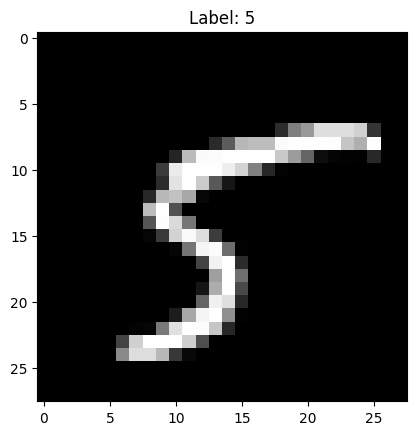

In [49]:
import matplotlib.pyplot as plt

sample_idx = torch.randint(len(mnist_train), size=(1,)).item()
img_raw, label = mnist_train[sample_idx]
print(f'Image size: {img_raw.shape}')
plt.imshow(img_raw.squeeze(), cmap='gray')
plt.title(f'Label: {label}')

# Saving the plot
path = Path('plots')
path.mkdir(parents=True, exist_ok=True)
plt.savefig(path / 'mnist_example.png')

plt.show()

In [5]:
# ToTensor, (height, width, channel) boyutlarında bir görseli/NumPy arrayi
# (channel, height, width) boyutlarında bir torch.FloatTensor e çevirir.
# Bu dönüşüm, modelin performansını arttırmaktadır.
# Ayrıca piksel değerlerini 255'e bölerek değerleri [0, 255] aralığından [0, 1] aralığına çeker.

torch.min(img_raw), torch.max(img_raw)

(tensor(0.), tensor(1.))

### Plotting the Class Distribution

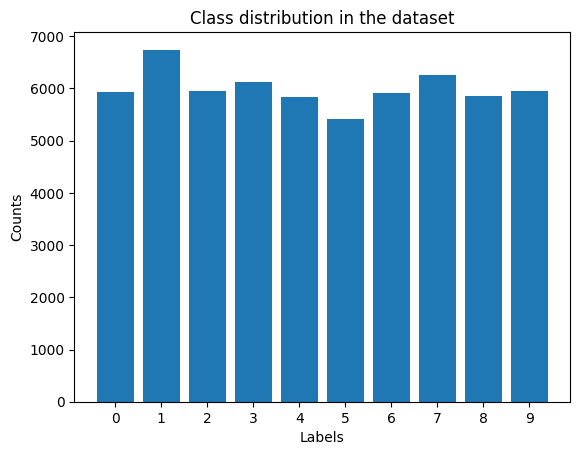

In [ ]:
labels, counts = np.unique(mnist_train.dataset.targets.numpy(), return_counts=True)

fig, ax = plt.subplots()
ax.bar(labels, counts)
ax.set_xticks(labels)
ax.set_ylabel('Counts')
ax.set_xlabel('Labels')
ax.set_title('Class distribution in the dataset')

# Saving the plot
path = Path('plots')
path.mkdir(parents=True, exist_ok=True)
plt.savefig(path / 'class_dist.png')

plt.show()


## Preprocessing

### Setting Up Transforms

In [59]:
# - RandomHorizontalFlip, görseli yatay eksene göre ters çevirir.
# - RandomAffine, görseli (-10, 10) arasında bir açı değeri kadar döndürür,
#   %20 sağa-sola/yukarı-aşağı kaydırır, %10 büyültür veya küçültür.

augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=(-10, 10), translate=(0.2, 0.2), scale=(0.90, 1.1)),
])

In [60]:
# Dataset'e gerekli dönüşümleri yapmamız için bir class tanımlıyoruz.

class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]

        if self.transform:
            x = self.transform(x)
        return x, y

### Transforming the Dataset

In [61]:
# Dataset'lere dönüşümleri uyguluyoruz.
# Training dataset'e manipüle edilmiş görselleri ekliyoruz.

mnist_train_augmented = TransformedDataset(mnist_train, transform=augmentation)
mnist_train = ConcatDataset([mnist_train, mnist_train_augmented])

print(f'Transformed training dataset size: {len(mnist_train)}')
print(f'Transformed validation dataset size: {len(mnist_validation)}')
print(f'Transformed test dataset size: {len(mnist_test)}')

Transformed training dataset size: 80000
Transformed validation dataset size: 20000
Transformed test dataset size: 10000


### Visualizing the Transformed Dataset

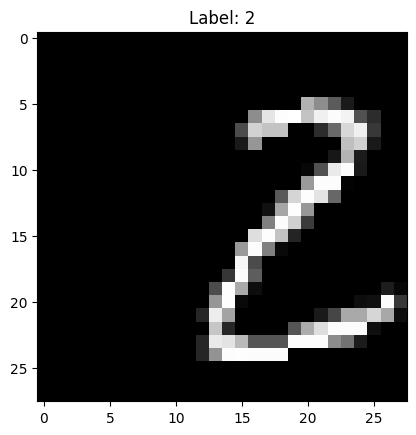

In [88]:
import matplotlib.pyplot as plt

sample_idx = torch.randint(len(mnist_train), size=(1,)).item()
img_transformed, label = mnist_train[sample_idx]
plt.imshow(img_transformed.squeeze(), cmap='gray')
plt.title(f'Label: {label}')

# Saving the plot
path = Path('plots')
path.mkdir(parents=True, exist_ok=True)
plt.savefig(path / 'augmentation.png')

plt.show()

### Adding Noise

In [10]:
# Görsellere gürültü eklemek için bir fonksiyon tanımlıyoruz.

def add_noise(image, noise_factor=0.5):
    noise = torch.randn_like(image) * noise_factor
    noisy_img = image + noise

    # Gürültüyü ekledikten sonra piksel değerlerini tekrar 0-1 aralığına çekmek için
    return torch.clamp(noisy_img, 0., 1.)

### Visualizing the Noisy Images

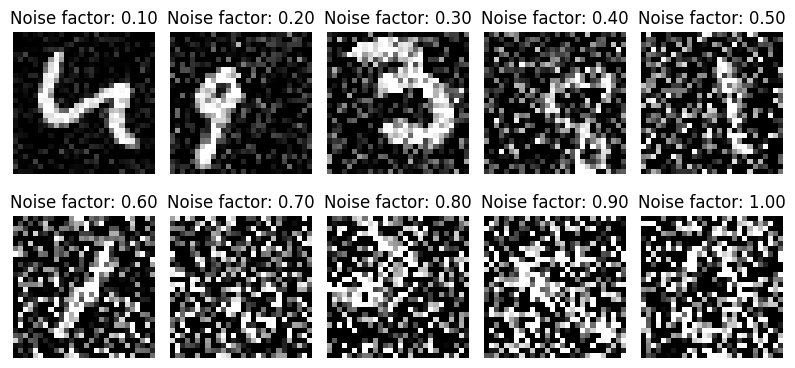

In [89]:
plt.figure(figsize=(8,4))

for idx, noise_factor in enumerate(np.linspace(0.1, 1, 10)):
  plt.subplot(2, 5, idx+1)
  sample_idx = torch.randint(len(mnist_train), size=(1,)).item()
  img, label = mnist_train[sample_idx]

  plt.imshow(add_noise(img, noise_factor=noise_factor).squeeze(), cmap='gray')
  plt.title(f'Noise factor: {noise_factor:.2f}')
  plt.axis('off')

plt.tight_layout()

# Saving the plot
path = Path('plots')
path.mkdir(parents=True, exist_ok=True)
plt.savefig(path / 'noisy_images.png')

plt.show()

In [12]:
# Dataset'i model tarafından kullanılmaya hazır hale getiriyoruz.

train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(mnist_validation, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False)

## Model Training / Testing

### Creating the Model

In [13]:
# Autoencoder'ımızı tasarlıyoruz.

class DenoisingAutoencoder(torch.nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # Modele giren görselin boyutu (1, 28, 28)

            # 1. Katman Bloğu
            # 16 tane 3x3 lük convolution filtresi uyguluyoruz, görselin üstünde kayarken 1 piksel ilerliyor (stride)
            # padding=1 demek, görselin etrafına 1 piksel kalınlığında 0'lardan oluşan bir "çerçeve" eklemektir.
            # Böylece görselin orijinal boyutu korunmuş olunur. 
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1),  # Çıktı: [Batch, 16, 28, 28]
            # Negatiflikten kurtulmak ve modeli non-linear hale getirmek için aktivasyon fonksiyonu
            nn.ReLU(),
            # Elde ettiğimiz matrisler 28x28 lik olacaktır. Her birinin üzerinden 2x2 filtreyle 2 piksel ilerlediğimizde
            # matrisin boyutu 14x14 lük olacaktır.
            nn.MaxPool2d(kernel_size=2, stride=2),     # Çıktı: [Batch, 16, 14, 14]
            
            # 2. Katman Bloğu
            # Burada da benzer işlemler yapıyoruz
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), # Çıktı: [Batch, 32, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),     # Çıktı: [Batch, 32, 7, 7] (Boyut Yarılandı)
            
            # 3. Latent Vector (Dar Boğaz)
            # Encodingin sonunda (1, 28, 28) lik bir görseli (64, 1, 1) lik bir vektöre sıkıştırdık
            nn.Conv2d(32, 64, 7) # Çıktı: [Batch, 64, 1, 1]
        )

        # Decoder
        self.decoder = nn.Sequential(
            # Buraya gelen görselin boyutu (64, 1, 1)
            # Convolutionun tersini yapar: 1 pikseli alır, bir filtreye yansıtır ve 7x7 lik bir matris elde eder
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=7), # Çıktı: [Batch, 32, 7, 7]
            # Yine aktivasyon fonksiyonundan geçiririz
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1), # Çıktı: [Batch, 16, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), # Çıktı: [Batch, 1, 28, 28]
            # Piksel değerlerini 0-1 arasına çekmek için
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [14]:
# Modelin mimarisi

model = DenoisingAutoencoder().to(device)
summary(model, input_size=(1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
DenoisingAutoencoder                     [1, 28, 28]               --
├─Sequential: 1-1                        [64, 1, 1]                --
│    └─Conv2d: 2-1                       [16, 28, 28]              160
│    └─ReLU: 2-2                         [16, 28, 28]              --
│    └─MaxPool2d: 2-3                    [16, 14, 14]              --
│    └─Conv2d: 2-4                       [32, 14, 14]              4,640
│    └─ReLU: 2-5                         [32, 14, 14]              --
│    └─MaxPool2d: 2-6                    [32, 7, 7]                --
│    └─Conv2d: 2-7                       [64, 1, 1]                100,416
├─Sequential: 1-2                        [1, 28, 28]               --
│    └─ConvTranspose2d: 2-8              [32, 7, 7]                100,384
│    └─ReLU: 2-9                         [32, 7, 7]                --
│    └─ConvTranspose2d: 2-10             [16, 14, 14]              4,62

### Training the Model

In [15]:
# Loss ve Optimizer
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
metrics = ['accuracy']

In [16]:
# Epoch-loss grafikleri için saklıyoruz
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
  # Modeli training moduna alıyoruz.
  # Bunu yapmamızın sebebi PyTorch'un training ve evaluation aşamalarında farklı ayarlar kullanmasıdır.
  model.train()
  running_loss = 0.0

  for data in train_loader:
    img, _ = data
    img = img.to(device) # Görseli GPU'ya atıyoruz

    # Gürültüyü ekliyoruz
    noisy_img = add_noise(img, NOISE_FACTOR)

    # PyTorch, bir sonraki batch'e geçtikten sonra bile önceki batch'te hesapladığı gradyanları
    # saklamaya devam etmektedir. Bu sebepten dolayı yeni gradyanlar eski gradyanlara eklenecektir (accumulation).
    # Ancak bu durum, yanlış parametre güncellemelerine yol açacaktır. Bunu önlemek için önceki batch'te
    # hesaplanılan gradyanları sıfırlamamız gerekir.
    optimizer.zero_grad()

    # Gürültülü görseli encode edip sıkıştırdıktan sonra decode edip
    # görseli yeniden inşa ediyoruz (reconstruction)
    output = model(noisy_img)
    # Orijinal görsel ile reconstructed görsel arasındaki MSE'yi hesaplıyoruz
    current_loss = loss(output, img)

    # Backpropagation ile gradyanları hesaplıyoruz
    current_loss.backward()
    # Parametreleri optimizasyon yöntemimize göre güncelliyoruz (Bu durumda ADAM)
    optimizer.step()

    # O batch'teki MSE'yi ekliyoruz
    running_loss += current_loss.item()

  # O epoch için modelin ortalama başarısını hesaplıyoruz.
  # # (MSE_batch_1 + MSE_batch_2 + ... + MSE_batch_n) / n 
  epoch_train_loss = running_loss / len(train_loader)
  train_losses.append(epoch_train_loss)

  # ----------------------------------------- VALIDATION -----------------------------------------

  # Modeli validasyon dataseti ile test ediyoruz ki elde ettiğimiz sonuçlara göre
  # modelin hiperparametrelerini güncelleyelim.

  # Modeli evaluation moduna alıyoruz
  model.eval()
  running_val_loss = 0.0

  # Modele gradyan hesaplamamasını söylüyoruz
  with torch.no_grad():
      for data in val_loader:
          img, _ = data

          # Görseli GPU'ya atıyoruz
          img = img.to(device)

          # Görsele gürültü ekliyoruz
          noisy_img = add_noise(img, NOISE_FACTOR)

          # Görsele "denoise" uyguluyoruz
          output = model(noisy_img)

          # MSE hesaplıyoruz yine
          current_loss = loss(output, img)
          running_val_loss += current_loss.item()

  # Epoch başı modelin ortalama başarısını hesaplıyoruz
  epoch_val_loss = running_val_loss / len(val_loader)
  val_losses.append(epoch_val_loss)

  print(f"Epoch [{epoch+1}/{EPOCHS}] \t Train loss: {epoch_train_loss:.5f} \t Validation loss: {epoch_val_loss:.5f}")

Epoch [1/10] 	 Train loss: 0.04406 	 Validation loss: 0.01855
Epoch [2/10] 	 Train loss: 0.01944 	 Validation loss: 0.01415
Epoch [3/10] 	 Train loss: 0.01666 	 Validation loss: 0.01311
Epoch [4/10] 	 Train loss: 0.01554 	 Validation loss: 0.01246
Epoch [5/10] 	 Train loss: 0.01490 	 Validation loss: 0.01201
Epoch [6/10] 	 Train loss: 0.01444 	 Validation loss: 0.01171
Epoch [7/10] 	 Train loss: 0.01415 	 Validation loss: 0.01155
Epoch [8/10] 	 Train loss: 0.01390 	 Validation loss: 0.01139
Epoch [9/10] 	 Train loss: 0.01374 	 Validation loss: 0.01126
Epoch [10/10] 	 Train loss: 0.01361 	 Validation loss: 0.01113


### Validating the Model

### Plotting the Training and Validation Losses

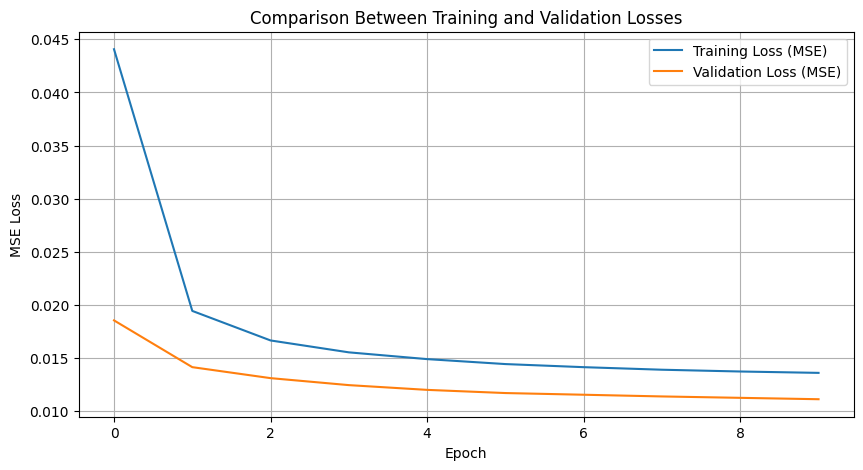

In [90]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss (MSE)')
plt.plot(val_losses, label='Validation Loss (MSE)')
plt.title('Comparison Between Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

# Saving the plot
path = Path('plots')
path.mkdir(parents=True, exist_ok=True)
plt.savefig(path / 'losses.png')

plt.show()

### Testing the Model

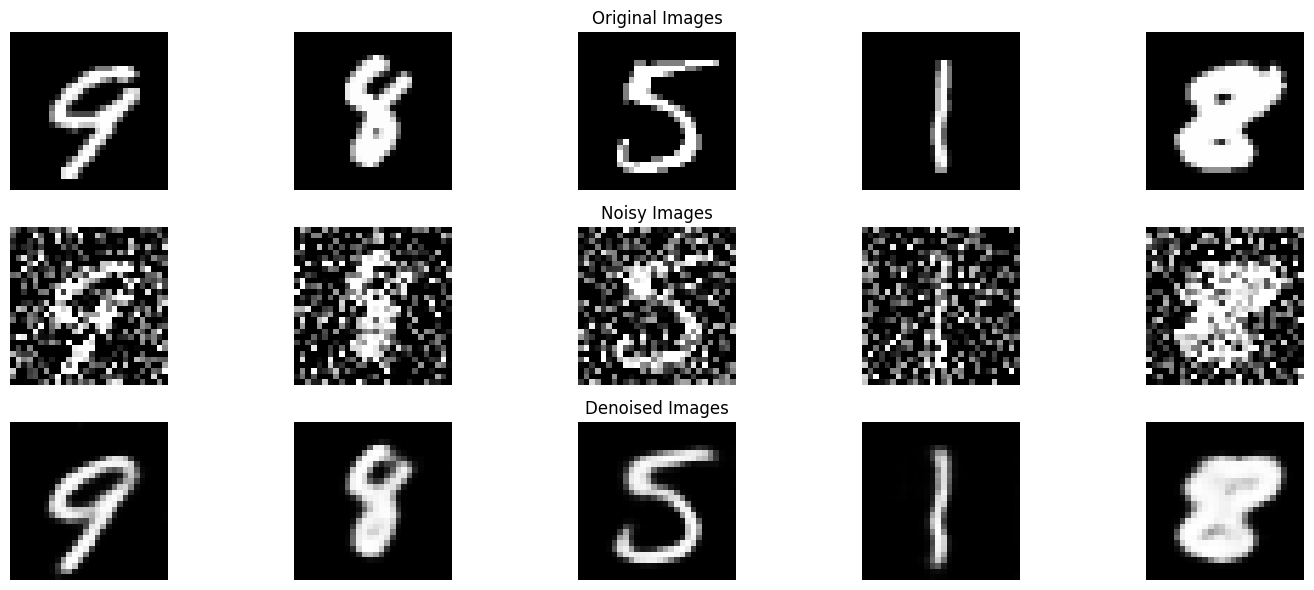

In [91]:
def visualize_results(model, dataset, num_images=5):
    # Modeli evaluation moduna alıyoruz
    model.eval()
    
    # num_images kadar görseli alıyoruz
    temp_loader = DataLoader(dataset, batch_size=num_images, shuffle=True)
    images, _ = next(iter(temp_loader))
    images = images.to(device)

    # Görsellere gürültü ekliyoruz
    noisy_images = add_noise(images, NOISE_FACTOR)

    # Gürültülü görseli "denoise" ediyoruz
    with torch.no_grad():
        outputs = model(noisy_images)

    # Görselleri CPU'ya alıyoruz ve numpy array'e çeviriyoruz
    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    # Görselleri plotluyoruz
    fig, axes = plt.subplots(3, num_images, figsize=(15, 6))
    plt.gray()

    # 1. satırda orijinal görseller
    # 2. satırda gürültülü görseller
    # 3. satırda denoise edilmiş görseller
    for i in range(num_images):

        # i. sütun 1. satır
        axes[0, i].imshow(images[i].reshape(28, 28))
        axes[0, i].axis('off')
        # Ortadaki görselin üstünde başlık
        if i == num_images // 2: axes[0, i].set_title("Original Images")

        # i. sütun 2. satır
        axes[1, i].imshow(noisy_images[i].reshape(28, 28))
        axes[1, i].axis('off')
        if i == num_images // 2: axes[1, i].set_title("Noisy Images")

        # i. sütun 3. satır
        axes[2, i].imshow(outputs[i].reshape(28, 28))
        axes[2, i].axis('off')
        if i == num_images // 2: axes[2, i].set_title("Denoised Images")

    plt.tight_layout()

    # Saving the plot
    path = Path('plots')
    path.mkdir(parents=True, exist_ok=True)
    plt.savefig(path / 'tests.png')

    plt.show()

visualize_results(model, mnist_test)

In [19]:
# Peak Signal-to-Noise Ratio

# <15 dB: Kötü
# 15-20 dB: Orta
# 20-25 dB: İyi
# >25 dB: Çok İyi 

def calculate_avg_psnr(model, loader):

    model.eval()
    total_psnr = 0.0
    num_batches = 0

    with torch.no_grad():
        for data in loader:
            img, _ = data
            img = img.to(device)

            noisy_img = add_noise(img, NOISE_FACTOR)
            output = model(noisy_img)

            # MSE Hesapla
            mse = torch.mean((output - img) ** 2)

            if mse == 0:
                total_psnr += 100

            else:
                max_pixel = 1.0
                psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
                total_psnr += psnr.item()

            num_batches += 1

    return total_psnr / num_batches

avg_psnr = calculate_avg_psnr(model, test_loader)

print(f"Average PSNR for test data: {avg_psnr:.2f} dB")

Average PSNR for test data: 19.61 dB
